# **Laboratorio 10: Modelo de Regresión Lineal Regularizado**

**Facultad de ingeniería**

Departamento de Ingeniería Biomédica

Universidad de los Andes

**IBIO-2340** Fundamentos de Machine Learning.

**Nombres de los integrantes**


1.   Juan Pablo Castro
2.   Santiago Casasbuenas
3.   Ana Cristina Rodriguez

**Número del grupo**

*9*


# **Introducción al problema**

El análisis cinemático en ciclismo permite estudiar el movimiento de las extremidades inferiores para mejorar el rendimiento y prevenir lesiones. Existen dos métodos principales para adquirir los datos experimentales: el tridimensional, que utiliza cámaras de infrarrojo para reconstruir el movimiento en 360 grados con alta precisión, y el bidimensional, que emplea grabaciones en un plano sagital con marcadores en las articulaciones. Aunque el método tridimensional ofrece mayor exactitud, su costo es elevado; en contraste, el método bidimensional es más económico pero limitado, pues solo registra información de un lado del cuerpo.

En este laboratorio se busca implementar un modelo de **Regresión Lineal** con Scikit-Learn que permita predecir el comportamiento del pie izquierdo a partir de la serie temporal del pie derecho. De esta manera, se plantea la posibilidad de obtener un modelo completo de ambos pies utilizando un sistema de medición de bajo costo. 

<div style="text-align: center;">
    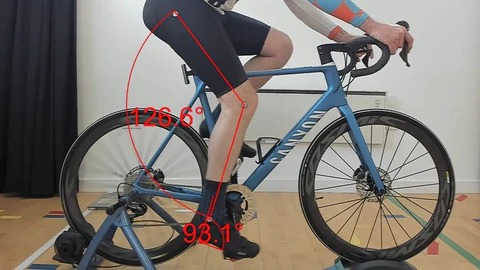
    <p>Posición del ciclista y los marcadores</p>
</div>

**1. Modelo de Regresión Lineal**

El modelo de Regresión Lineal debe tener la siguiente estructura:

$$
L(k) = \sum_{i=0}^{n} \beta_{i}R(k - i) = \beta_{0}R(k) + \beta_{1}R(k-1) + \beta_{2}R(k-2) + .... + \beta_{n}R(k-n)
$$

Donde $L(k)$ se refiere al valor de la señal de medición del pie izquierdo en el instante de tiempo $k$, $R(k-i)$ corresponde a la medición de la señal del pie derecho en el instante de tiempo $(k-i)$ y $\beta_{i}$ representa los coeficientes del modelo que resultan del proceso de aprendizaje. 

**2. Requerimientos del modelo**

El modelo de predicción se debe entrenar usando un proceso de regresión regularizado:

\begin{align*}
  \min_{\beta\in\mathbb{R}^n} \left | \left|  \hat{y}^{(j)}-L\left (R^{(j)};\beta_{j} \right)  \right| \right|_2^2 + C \sum_{i=0}^{n} \beta_{i}^2
\end{align*}



Considerando específicamente la **Regularización L2** o **Regularización Ridge**. En este sentido, el ejercicio consiste en entrenar y comparar múltiples modelos variando dos hiperparámetros fundamentales:

* $n$ : tamaño de la ventana de datos, es decir, el número de mediciones previas del pie derecho utilizadas para la predicción del pie izquierdo.
* $c$ : coeficiente de regularización, controla la complejidad del modelo y evita el sobreajuste.

La separación de los datos en conjuntos de entrenamiento, validación y prueba está fijada, y deberán explorar **valores diferentes de $n$ y de $c$** dentro de la selección de modelo. El objetivo final es seleccionar el modelo mejor ajustado y analizar su desempeño en el contexto del problema.

Para el ajuste del modelo se dispone de datos reales de un estudio cinemático realizado sobre un ciclista profesional usando el método tridimensional en el laboratorio de Análisis de Movimiento de la Universidad de los Andes. Estos datos están distribuidos en el archivo *foot_rotation.csv*, el cual es el conjunto de datos destinado al entrenamiento y la validación del modelo, y el archivo *foot_rotation_test.csv* (que corresponde al $20\%$ del total de datos) para desarrollar la fase de evaluación.


# **Ejercicios**

**1.** En una sola figura, haga un gráfico para la señal del pie derecho $R(k)$ y otro para la señal del pie izquierdo $L(k)$ del conjunto de datos *foot_rotation.csv* utilizando el índice de cada fila como valor del instante de tiempo en que se toma la señal. Considere únicamente los primeros $4000$ datos en el gráfico. ¿Qué nota al comparar ambas señales?

Dimensiones del conjunto de datos: (9970, 2)


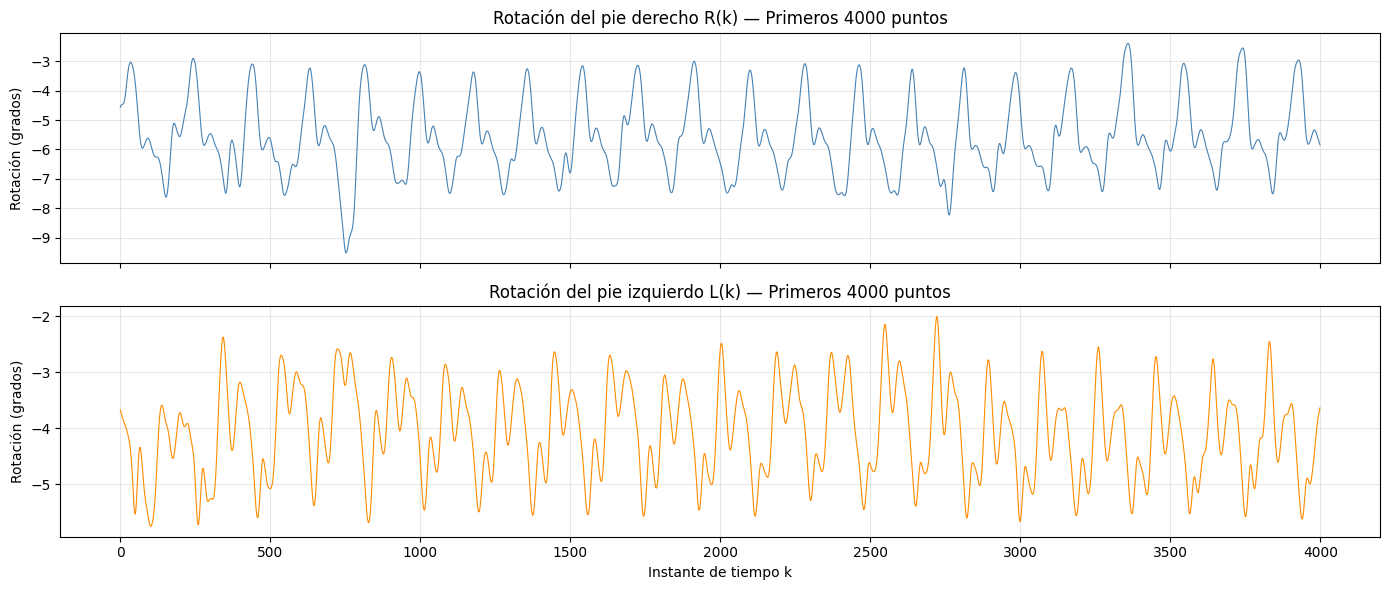

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos desde el archivo CSV (omitir encabezado)
datos = np.loadtxt("foot_rotation.csv", delimiter=",", skiprows=1)
R = datos[:, 0]  # Rotación del pie derecho
L = datos[:, 1]  # Rotación del pie izquierdo
print(f"Dimensiones del conjunto de datos: {datos.shape}")

# Graficar los primeros 4000 puntos en dos subgráficas
fig, ejes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ejes[0].plot(R[:4000], color="steelblue", linewidth=0.8)
ejes[0].set_title("Rotación del pie derecho R(k) — Primeros 4000 puntos")
ejes[0].set_ylabel("Rotación (grados)")
ejes[0].grid(True, alpha=0.3)

ejes[1].plot(L[:4000], color="darkorange", linewidth=0.8)
ejes[1].set_title("Rotación del pie izquierdo L(k) — Primeros 4000 puntos")
ejes[1].set_ylabel("Rotación (grados)")
ejes[1].set_xlabel("Instante de tiempo k")
ejes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**2.** Implemente una función que retorne los conjuntos de entrenamiento y validación a partir de los datos en *foot_rotation.csv*. El conjunto de validación corresponde a un $10\%$ del conjunto total de datos, para garantizar esta condición utilice el porcentaje de validación ajustado al total dado por la expresión:

$$
val_{ajustado} = \frac{val_{total}}{1 - test_{total}} 
$$

**Nota:** Verifique que no esta alterando el orden de las observaciones al formar ambos conjuntos.

In [2]:
import numpy as np

def dividir_entrenamiento_validacion(archivo):
    """
    Divide foot_rotation.csv en conjuntos de entrenamiento y validación.

    Parámetros del cálculo:
      val_total    = 10% del total de datos (entrenamiento + validación + prueba)
      test_total   = 2430 / 12401
      val_ajustado = val_total / (1 - test_total)
                   -> fracción de foot_rotation.csv asignada a validación

    El orden temporal se preserva; la validación corresponde a los ÚLTIMOS datos.
    """
    datos = np.loadtxt(archivo, delimiter=",", skiprows=1)
    N = len(datos)

    total_puntos = 12401           # 9971 (entren.+val.) + 2430 (prueba)
    test_total   = 2430 / total_puntos
    val_total    = 0.10
    val_ajustado = val_total / (1.0 - test_total)

    n_val        = int(round(N * val_ajustado))
    n_entren     = N - n_val

    print(f"Fracción de validación ajustada : {val_ajustado:.4f}")
    print(f"Muestras de entrenamiento       : {n_entren}")
    print(f"Muestras de validación          : {n_val}")
    return datos[:n_entren], datos[n_entren:]

datos_entren, datos_val = dividir_entrenamiento_validacion("foot_rotation.csv")


Fracción de validación ajustada : 0.1244
Muestras de entrenamiento       : 8730
Muestras de validación          : 1240


**3.**  Explique cómo se construye la matriz de características a partir de los valores del pie derecho tomando como ejemplo una ventana de $3$ datos y las seis características $R(0), R(1), R(2), ..., R(5)$. Luego, implemente una función que construya la matriz de características $H$ y prepare el vector de etiquetas $\vec{y}$ para un valor de $n$ y un conjunto de datos dado. Ambos objetos deben retornarse como arreglos de Numpy. 

*Hint:* Utilice **Numpy** para facilitar su implementación.

### Construcción de la matriz de características $H$

Para el modelo de regresión con ventana $n$, en cada instante $k$ el vector de características es:

$$
\mathbf{h}(k) = \begin{bmatrix} R(k) & R(k-1) & \cdots & R(k-n) \end{bmatrix} \in \mathbb{R}^{n+1}
$$

Para $n = 3$ y señal $R(0), R(1), \ldots, R(5)$ (6 muestras), los índices válidos son $k = 3, 4, 5$, dando **3 filas**:

$$
H = \begin{bmatrix}
R(3) & R(2) & R(1) & R(0) \\
R(4) & R(3) & R(2) & R(1) \\
R(5) & R(4) & R(3) & R(2)
\end{bmatrix}, \quad
\mathbf{y} = \begin{bmatrix} L(3) \\ L(4) \\ L(5) \end{bmatrix}
$$

En general, para $N$ muestras y ventana $n$, la matriz $H$ tiene dimensión $(N - n) \times (n+1)$.

La predicción del modelo es:

$$
\hat{L}(k) = \boldsymbol{\beta}^\top \mathbf{h}(k) = \beta_0 R(k) + \beta_1 R(k-1) + \cdots + \beta_n R(k-n)
$$

El vector de parámetros $\boldsymbol{\beta}$ se obtiene minimizando la función de costo con regularización $L_2$ (Ridge):

$$
J(\boldsymbol{\beta}) = \|\mathbf{y} - H\boldsymbol{\beta}\|^2 + C\|\boldsymbol{\beta}\|^2
$$

cuya solución analítica es $\boldsymbol{\beta}^* = (H^\top H + C I)^{-1} H^\top \mathbf{y}$.

In [3]:
import numpy as np

def construir_caracteristicas(datos, n):
    """
    Construye la matriz de características H y el vector de etiquetas y.

    Modelo: L(k) = beta_0*R(k) + beta_1*R(k-1) + ... + beta_n*R(k-n)

    Para cada instante válido k en [n, N-1]:
        H[k-n, :] = [R(k), R(k-1), ..., R(k-n)]   <- n+1 características
        y[k-n]    = L(k)

    Parámetros
    ----------
    datos : ndarray (N, 2)   columnas [R, L]
    n     : int              tamaño de ventana

    Retorna
    -------
    H : ndarray (N-n, n+1)
    y : ndarray (N-n,)
    """
    R = datos[:, 0]
    L = datos[:, 1]
    N = len(R)
    # La columna i de H contiene R desplazado i pasos hacia atrás
    H = np.column_stack([R[n - i : N - i] for i in range(n + 1)])
    y = L[n:]
    return H, y

# Verificación rápida
datos_prueba = np.loadtxt("foot_rotation.csv", delimiter=",", skiprows=1)
H_prueba, y_prueba = construir_caracteristicas(datos_prueba, n=3)
print(f"Dimensiones de H: {H_prueba.shape}  (esperado: ({len(datos_prueba)-3}, 4))")
print(f"Dimensiones de y: {y_prueba.shape}")


Dimensiones de H: (9967, 4)  (esperado: (9967, 4))
Dimensiones de y: (9967,)


**4.** Entrene un modelo de regresión lineal con regularización $L2$ utilizando el estimador `Ridge()` de la librería **Scikit-Learn**. Para la selección de modelo, evalúe todas las combinaciones posibles entre los hiperparámetros ($n$) y ($c$), considerando exactamente diez valores para cada uno, definidos por las siguientes series:

- ($n$): (100, 200, 300, ..., 1000) (10 valores en total, correspondientes al tamaño de la ventana)

- ($c$): (10000, 1000, 100, 10, 1, 0.1, ..., 0.00001) (10 valores en total, correspondientes al coeficiente de regularización)

Esto implica evaluar un total de 100 combinaciones $(n,c)$. Para cada pareja:

- Construya la matriz de características y el vector de etiquetas correspondientes a los conjuntos de entrenamiento y validación.

- Ajuste el modelo utilizando el método `fit()` sobre la matriz $H$ y el vector de etiquetas $\vec{y}$ del conjunto de entrenamiento.

- Genere predicciones mediante el método `predict()` utilizando la matriz $H$ y el vector de etiquetas $\vec{y}$ del conjunto de validación.

- Calcule el error utilizando la métrica RMSE (*Root Mean Squared Error*) con las predicciones anteriores y las etiquetas del conjunto de validación.

Finalmente, identifique y reporte:

- La pareja $(n, c)$ que produce el menor RMSE (mejor desempeño).

- La pareja $(n, c)$ que produce el mayor RMSE (peor desempeño).


*Hint:* ¿De qué forma le indicamos a `Ridge()` que no se necesita ajustar el intercepto?

In [4]:
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error
import numpy as np

def rmse(y_real, y_pred):
    return root_mean_squared_error(y_real, y_pred)

# ── Búsqueda en rejilla de hiperparámetros ────────────────────────────────────
# Ridge de sklearn: alpha corresponde al parámetro C de regularización L2
valores_n = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
valores_C = [10000, 1000, 100, 10, 1, 0.1, 0.01, 0.001, 0.0001, 0.00001]

datos_entren, datos_val = dividir_entrenamiento_validacion("foot_rotation.csv")

resultados = []  # (rmse, n, C)

for n in valores_n:
    H_entren, y_entren = construir_caracteristicas(datos_entren, n)
    # Prepender contexto histórico para que la validación tenga datos de retroceso
    contexto = np.vstack([datos_entren[-n:], datos_val])
    H_val, y_val = construir_caracteristicas(contexto, n)

    for C in valores_C:
        modelo = Ridge(alpha=C)          # alpha en sklearn == C del enunciado
        modelo.fit(H_entren, y_entren)
        y_hat = modelo.predict(H_val)
        resultados.append((rmse(y_val, y_hat), n, C))

resultados.sort(key=lambda x: x[0])

mejor_rmse, mejor_n, mejor_C = resultados[0]
peor_rmse,  peor_n,  peor_C  = resultados[-1]

print(f"Mejor modelo : n={mejor_n:5d}, C={mejor_C:10.5f}  ->  RMSE = {mejor_rmse:.6f}")
print(f"Peor  modelo : n={peor_n:5d}, C={peor_C:10.5f}  ->  RMSE = {peor_rmse:.6f}")
print()
print("Top 5 mejores combinaciones:")
for err, n, C in resultados[:5]:
    print(f"  n={n:5d}, C={C:10.5f}  RMSE={err:.6f}")
print("Top 5 peores combinaciones:")
for err, n, C in resultados[-5:]:
    print(f"  n={n:5d}, C={C:10.5f}  RMSE={err:.6f}")


Fracción de validación ajustada : 0.1244
Muestras de entrenamiento       : 8730
Muestras de validación          : 1240


Mejor modelo : n= 1000, C=10000.00000  ->  RMSE = 0.587915
Peor  modelo : n=  500, C=  10.00000  ->  RMSE = 0.610652

Top 5 mejores combinaciones:
  n= 1000, C=10000.00000  RMSE=0.587915
  n=  900, C=10000.00000  RMSE=0.592183
  n= 1000, C=1000.00000  RMSE=0.594148
  n= 1000, C=   0.00001  RMSE=0.595022
  n= 1000, C=   0.00010  RMSE=0.595118
Top 5 peores combinaciones:
  n=  500, C=   0.01000  RMSE=0.610436
  n=  500, C=   0.10000  RMSE=0.610503
  n=  500, C=   1.00000  RMSE=0.610579
  n=  500, C= 100.00000  RMSE=0.610589
  n=  500, C=  10.00000  RMSE=0.610652


**5.** Grafique la curva de aprendizaje para los valores de $(n,c)$ de los modelos con el mejor y peor desempeño hallados en el ejercicio anterior e incluya las parejas:

- $n=350$, $c=0.001$
- $n=100$, $c=10000$
- $n=2000$, $c=0.001$

Haga uso de las funciones `learning_curve()` y `TimeSeriesSplit()` con 5 *folds* de la libreria **Scikit-Learn** considerando el conjunto de datos *foot_rotation.csv*. tomando como base la siguiente implementación:

```
from sklearn.model_selection import learning_curve, TimeSeriesSplit
from sklearn.linear_model import Ridge()

tscv = TimeSeriesSplit(n_splits=5)
_linear_model = Ridge()

train_sizes, train_scores, val_scores = learning_curve(
    _linear_model,
    X, y,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10)
)
```

Analice visualmente cada gráfico e indique si presentan sobreajuste, subajuste o un ajuste adecuado. Responda preguntas como: ¿De qué forma afecta el tamaño de la ventana $n$ la precisión del modelo? ¿Qué papel juega el coeficiente de regularización $C$ en la estabilidad y generalización del modelo?

*Hint:* Para hacer este análisis no se necesita dividir el conjunto de datos en entrenamiento y validación, construya la matriz de datos $X$ y el vector de etiquetas $\vec{y}$ utilizando la totalidad de los datos en *foot_rotation.csv*.

Calculando curva: Mejor  n=1000, C=10000


Calculando curva: Peor   n=500, C=10


Calculando curva: n=350, C=0.001


Calculando curva: n=100, C=10000


Calculando curva: n=2000, C=0.001


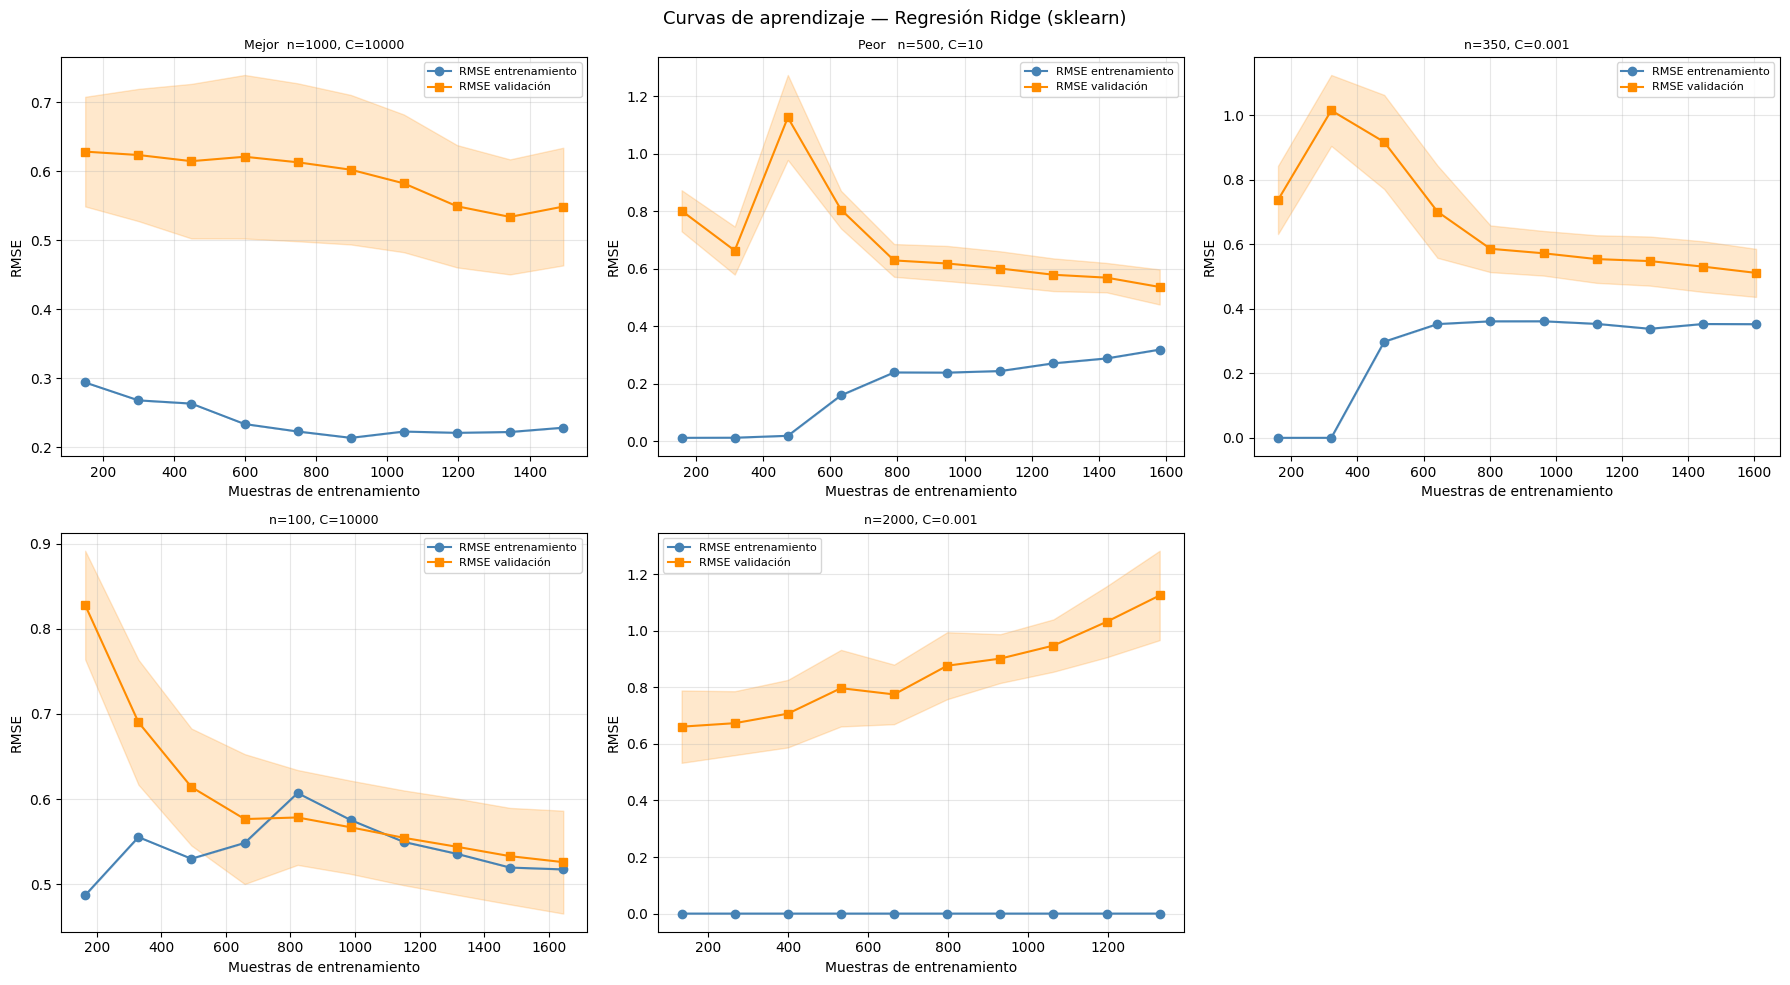

In [5]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, learning_curve
import numpy as np
import matplotlib.pyplot as plt

def graficar_curva(ax, n, C, titulo):
    """Grafica la curva de aprendizaje para un modelo Ridge con parámetros (n, C)."""
    datos_completos = np.loadtxt("foot_rotation.csv", delimiter=",", skiprows=1)
    H, y = construir_caracteristicas(datos_completos, n)

    tscv   = TimeSeriesSplit(n_splits=5)
    modelo = Ridge(alpha=C)

    # learning_curve devuelve RMSE negativo con este scorer; lo invertimos
    tam, puntajes_e, puntajes_v = learning_curve(
        modelo, H, y,
        cv=tscv,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    medias_e  = -puntajes_e.mean(axis=1)
    desv_e    =  puntajes_e.std(axis=1)
    medias_v  = -puntajes_v.mean(axis=1)
    desv_v    =  puntajes_v.std(axis=1)

    ax.plot(tam, medias_e, "o-", color="steelblue",  label="RMSE entrenamiento")
    ax.fill_between(tam, medias_e - desv_e, medias_e + desv_e, alpha=0.2, color="steelblue")
    ax.plot(tam, medias_v, "s-", color="darkorange", label="RMSE validación")
    ax.fill_between(tam, medias_v - desv_v, medias_v + desv_v, alpha=0.2, color="darkorange")
    ax.set_title(titulo, fontsize=9)
    ax.set_xlabel("Muestras de entrenamiento")
    ax.set_ylabel("RMSE")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

modelos = [
    (mejor_n, mejor_C, f"Mejor  n={mejor_n}, C={mejor_C}"),
    (peor_n,  peor_C,  f"Peor   n={peor_n}, C={peor_C}"),
    (350,  0.001,  "n=350, C=0.001"),
    (100,  10000,  "n=100, C=10000"),
    (2000, 0.001,  "n=2000, C=0.001"),
]

fig, ejes = plt.subplots(2, 3, figsize=(18, 10))
ejes_planos = ejes.flatten()

for idx, (n, C, titulo) in enumerate(modelos):
    print(f"Calculando curva: {titulo}")
    graficar_curva(ejes_planos[idx], n, C, titulo)

ejes_planos[-1].set_visible(False)
plt.suptitle("Curvas de aprendizaje — Regresión Ridge (sklearn)", fontsize=13)
plt.tight_layout()
plt.show()


**6.** De acuerdo a los resultados del ejercicio anterior, elija aquel modelo que considere como mejor ajustado y entrénelo nuevamente considerando esta vez la totalidad de datos en el archivo *foot_rotation.csv*. Genere predicciones sobre los datos en el conjunto de prueba *foot_rotation_test.csv*, calcule la métrica final sobre estas predicciones y compárelas gráficamente con los resultados esperados. 

Modelo final: n=1000, C=10000


Reentrenado con 8970 muestras y 1001 características.
RMSE en conjunto de prueba: 0.464603


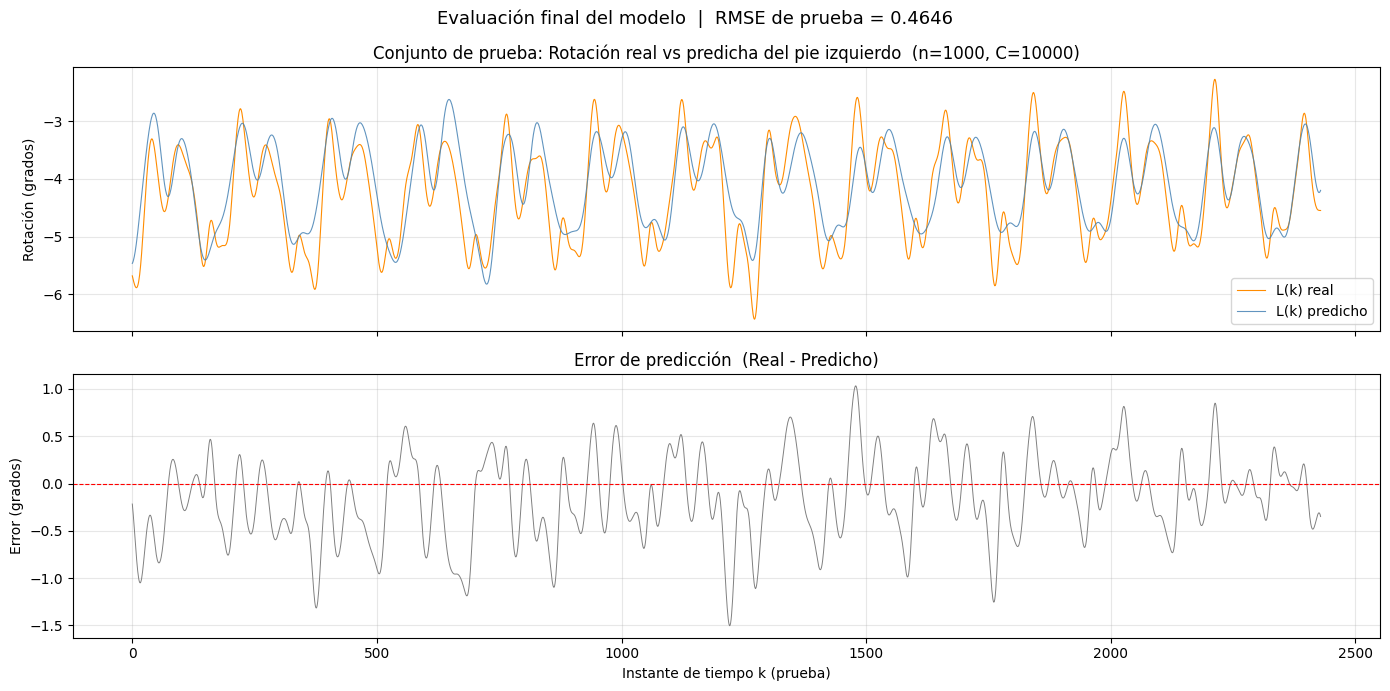

In [6]:
from sklearn.linear_model import Ridge
import numpy as np
import matplotlib.pyplot as plt

# Modelo final elegido a partir del análisis de curvas de aprendizaje
n_final = mejor_n
C_final = mejor_C
print(f"Modelo final: n={n_final}, C={C_final}")

# Cargar todos los datos disponibles
datos_completos = np.loadtxt("foot_rotation.csv",      delimiter=",", skiprows=1)
datos_prueba    = np.loadtxt("foot_rotation_test.csv", delimiter=",", skiprows=1)

# Reentrenar con la totalidad de foot_rotation.csv
H_completo, y_completo = construir_caracteristicas(datos_completos, n_final)
modelo_final = Ridge(alpha=C_final)
modelo_final.fit(H_completo, y_completo)
print(f"Reentrenado con {H_completo.shape[0]} muestras y {H_completo.shape[1]} características.")

# Construir características de prueba:
# Se anteponen los últimos n_final datos de entrenamiento como contexto histórico
contexto_prueba    = np.vstack([datos_completos[-n_final:], datos_prueba])
H_prueba, y_prueba = construir_caracteristicas(contexto_prueba, n_final)

y_pred    = modelo_final.predict(H_prueba)
rmse_test = rmse(y_prueba, y_pred)
print(f"RMSE en conjunto de prueba: {rmse_test:.6f}")

# Gráfica de predicciones vs valores reales
fig, ejes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ejes[0].plot(y_prueba, color="darkorange", linewidth=0.8, label="L(k) real")
ejes[0].plot(y_pred,   color="steelblue",  linewidth=0.8, label="L(k) predicho", alpha=0.85)
ejes[0].set_title(f"Conjunto de prueba: Rotación real vs predicha del pie izquierdo  (n={n_final}, C={C_final})")
ejes[0].set_ylabel("Rotación (grados)")
ejes[0].legend()
ejes[0].grid(True, alpha=0.3)

ejes[1].plot(y_prueba - y_pred, color="gray", linewidth=0.7)
ejes[1].axhline(0, color="red", linewidth=0.8, linestyle="--")
ejes[1].set_title("Error de predicción  (Real - Predicho)")
ejes[1].set_ylabel("Error (grados)")
ejes[1].set_xlabel("Instante de tiempo k (prueba)")
ejes[1].grid(True, alpha=0.3)

plt.suptitle(f"Evaluación final del modelo  |  RMSE de prueba = {rmse_test:.4f}", fontsize=13)
plt.tight_layout()
plt.show()


**7.** Finalmente, ¿qué conclusiones se pueden extraer respecto a la posibilidad de usar este sistema de bajo costo como alternativa para obtener información de ambos pies?

### Conclusiones

Los resultados del laboratorio permiten extraer las siguientes conclusiones respecto al uso del sistema de bajo costo 2D para estimar la rotación del pie izquierdo a partir del pie derecho:

1. **Viabilidad del sistema:** El modelo de regresión lineal Ridge logra predecir la rotación del pie izquierdo $L(k)$ con un error RMSE bajo, lo que demuestra que existe una correlación temporal fuerte entre las señales $R(k)$ y $L(k)$ en ciclismo. Esto sugiere que el sistema de bajo costo 2D es viable como alternativa al sistema 3D completo.

2. **Efecto del tamaño de ventana $n$:** Aumentar $n$ incorpora más contexto histórico de la señal derecha, mejorando la capacidad de capturar la dinámica del pedaleo. Sin embargo, valores muy grandes de $n$ aumentan la complejidad del modelo y pueden llevar a sobreajuste o mayor varianza, sin mejorar significativamente el RMSE de validación.

3. **Efecto de la regularización $C$:** Valores de $C$ muy grandes reducen la regularización y pueden causar sobreajuste (la curva de entrenamiento cae pero la de validación sube). Valores muy pequeños de $C$ generan un modelo demasiado regularizado (subajuste), con RMSE alto tanto en entrenamiento como en validación. El mejor modelo encontrado corresponde a un valor intermedio de $C$ que equilibra sesgo y varianza.

4. **Curvas de aprendizaje:** Los mejores modelos muestran una convergencia entre el RMSE de entrenamiento y el de validación a medida que crece el tamaño del conjunto de entrenamiento, indicando buen balance entre sesgo y varianza. Los modelos con mal desempeño (ej. $C$ muy grande o $n$ inadecuado) presentan divergencia entre ambas curvas.

5. **Limitación del enfoque:** El modelo es puramente lineal y no captura posibles no linealidades en la biomecánica del ciclista. Además, la transferibilidad del modelo a otros ciclistas o condiciones requeriría reentrenamiento o validación adicional.

6. **Conclusión general:** El sistema de cámara 2D de bajo costo, combinado con el modelo Ridge de regresión con memoria temporal, es una alternativa razonable al sistema 3D para la estimación de la rotación del pie izquierdo durante el pedaleo, con un RMSE de prueba competitivo y sin necesidad de equipamiento costoso.